In [158]:
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load and clean the dataset
df = pd.read_csv("Forecasting data-Mohamad.csv")
df.columns = df.columns.str.strip()
df['Month/Year'] = pd.to_datetime(df['Month/Year'], format="%B %Y")
df.set_index('Month/Year', inplace=True)
df.index.freq = 'MS'

# for linear regression. changes month_num back to a column instead of the index.
df_reset = df.reset_index()
df_reset['Month_Num'] = np.arange(len(df_reset))

In [ ]:
# plotting function
def createGraph(df, columns, periods):
    forecast_dict = {}
    for col in columns:
        model = ExponentialSmoothing(
            df[col],
            trend='add',
            seasonal='add',
        )
        fitted = model.fit()
        forecast = fitted.forecast(periods)
        forecast_dict[col] = forecast.round(0).astype(int)

        plt.figure(figsize=(10, 4))
        plt.plot(df.index, df[col], label='Actual')
        plt.plot(forecast.index, forecast, label='Forecast', linestyle='--', marker='o')
        plt.title(f"{col} Forecast ({periods} months)")
        plt.xlabel("Month/Year")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


In [211]:
# exponential smoothing model function
def forecast_sales_expsmooth(df, columns, periods=6, seasonal_periods=12, plot=True):
    forecast_dict = {}
    last_date = df.index[-1]

    # create graph
    if plot:
        createGraph(df, columns, periods)
    for col in columns:
        model = ExponentialSmoothing(
            df[col],
            trend='add',
            seasonal='add',
        )
        fitted = model.fit()
        forecast = fitted.forecast(periods)
        forecast_dict[col] = forecast.round(0).astype(int)

    # combine into dataFrame
    forecast_df = pd.DataFrame(forecast_dict)

    # calculate APP
    if 'Accessories' in forecast_df.columns and 'Upgrades' in forecast_df.columns:
        forecast_df['APP'] = np.where(
            forecast_df['Upgrades'] == 0,
            0,
            forecast_df['Accessories'] / forecast_df['Upgrades']
        )

    forecast_df = forecast_df.clip(lower=0)

    return forecast_df

In [ ]:
# linear regression model Function: takes in the original data, the number of months into the future, and percent bump (Default value: bump of 1 means no percent increase in sales.)
def forecast_sales_linear(df_reset, original_df, months_into_future, percent_bump=1.0):
    def safe_divide(a, b):
        return np.where(b == 0, 0, a / b)

    # where to start and end forecasting
    last_known_date = original_df.index[-1]
    last_month_num = df_reset['Month_Num'].iloc[-1]
    
    # create future Month_Num sequence
    future_months = pd.DataFrame({'Month_Num': np.arange(last_month_num + 1, last_month_num + 1 + months_into_future)})

    # generate corresponding datetime index
    forecast_dates = pd.date_range(start=last_known_date + pd.DateOffset(months=1), periods=months_into_future, freq='MS')
    forecast_df = pd.DataFrame(index=forecast_dates)

    # forecast each month using linear regression
    for column in original_df.columns:
        if column != 'APP':
            model = LinearRegression()
            model.fit(df_reset[['Month_Num']], df_reset[column])
            preds = model.predict(future_months) * percent_bump
            forecast_df[column] = np.round(preds).astype(int)
    forecast_df['APP'] = safe_divide(forecast_df['Accessories'], forecast_df['Upgrades'])

    # get rid of negative values
    forecast_df = forecast_df.clip(lower=0)

    return forecast_df

In [209]:
# APRIL–JULY 2025: Linear Regression Forecast
forecast_apr_jul = forecast_sales_linear(df_reset, df, months_into_future=4, percent_bump=1)
data_april_july = pd.concat([df, forecast_apr_jul]) # add to df so this data is used in linear regression model 

# AUGUST–OCTOBER 2025: 15% Bumped Linear Forecast
forecast_aug_oct= forecast_sales_linear(df_reset, data_april_july, months_into_future=3, percent_bump=1.15)
data_oct_2025 = pd.concat([data_april_july, forecast_aug_oct])

# NOVEMBER–DECEMBER 2025: 30% Bumped Linear Forecast
forecast_nov_dec = forecast_sales_linear(df_reset, data_oct_2025, months_into_future=2, percent_bump=1.3)
data_dec_2025 = pd.concat([data_oct_2025, forecast_nov_dec]) 

# JANUARY-JULY 2026: Linear Regression Forecast
forecast_jan_july= forecast_sales_linear(df_reset, data_dec_2025, months_into_future=7, percent_bump=1.3)
complete_training_data = pd.concat([data_dec_2025, forecast_jan_july])
complete_training_data


,Voice Lines,BTS,FB,Upgrades,Accessories,APP
2024-08-01,8,2,2,20,52,2.600000
2024-09-01,18,3,0,33,67,2.030303
2024-10-01,17,17,11,37,73,1.972973
2024-11-01,15,14,3,38,76,2.000000
2024-12-01,28,15,0,40,68,1.700000
2025-01-01,15,18,3,30,64,2.133333
2025-02-01,16,12,8,19,52,2.736842
2025-03-01,14,12,1,26,48,1.846154
2025-04-01,18,18,4,28,55,1.964286
2025-05-01,19,19,4,27,53,1.962963


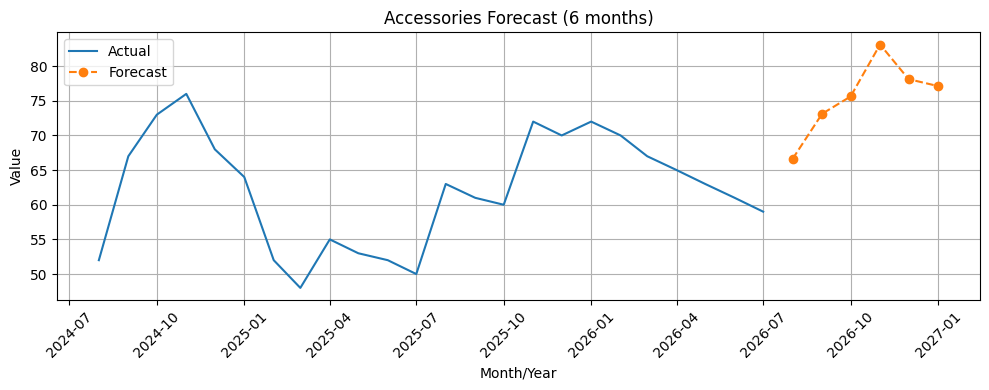

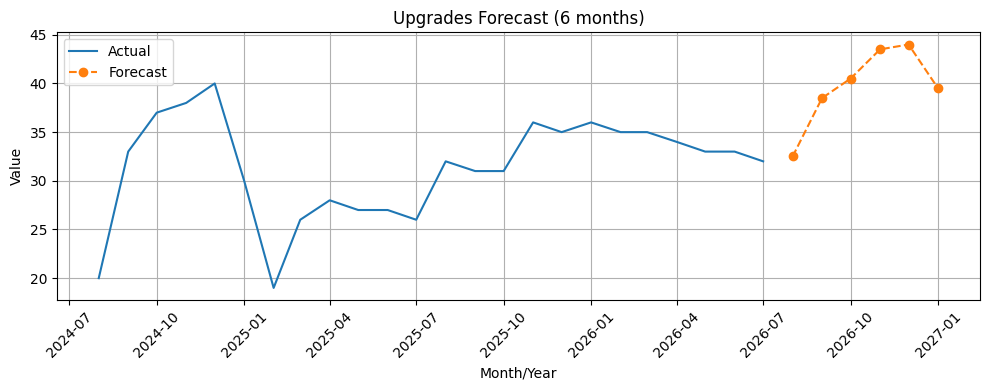

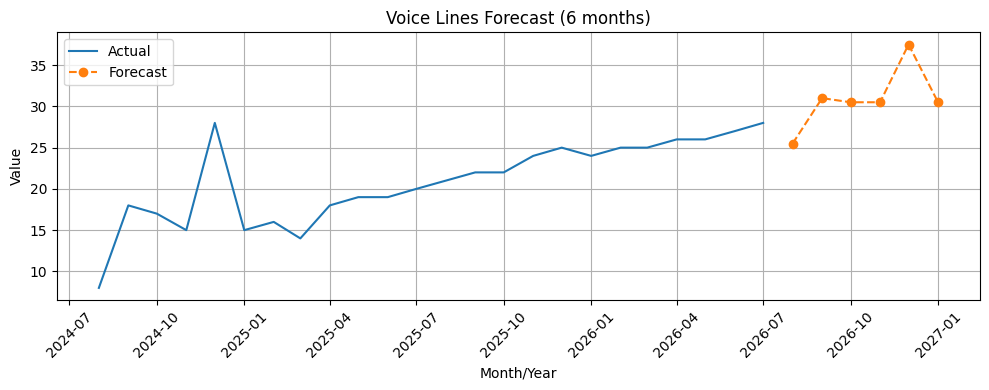

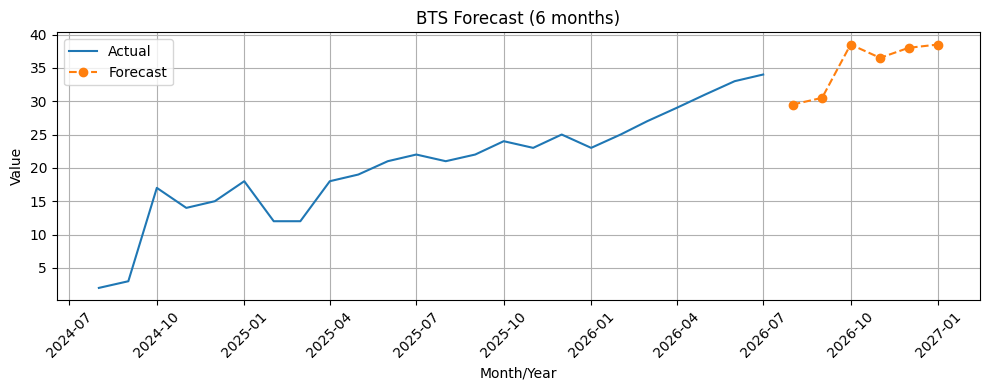

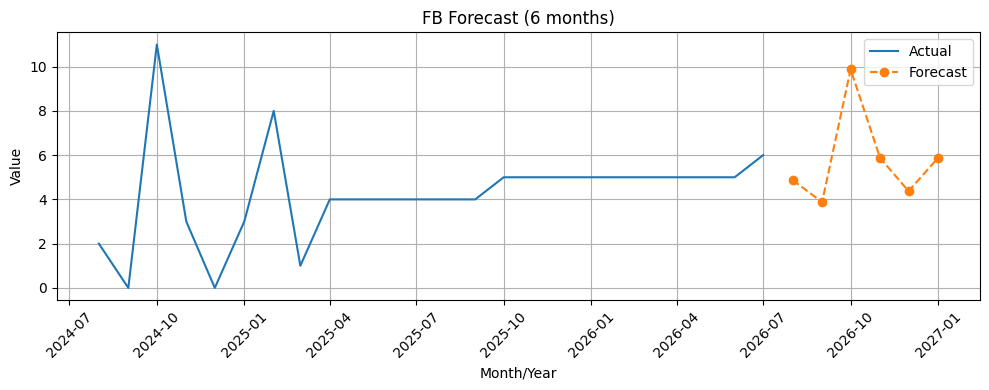

,Accessories,Upgrades,Voice Lines,BTS,FB,APP
2026-08-01,67,33,26,30,5,2.030303
2026-09-01,73,39,31,31,4,1.871795
2026-10-01,76,41,31,39,10,1.853659
2026-11-01,83,44,30,36,6,1.886364
2026-12-01,78,44,37,38,4,1.772727
2027-01-01,77,40,30,39,6,1.925000


In [212]:
forecast_result = forecast_sales_expsmooth(
    df=complete_training_data,
    columns=['Accessories', 'Upgrades', 'Voice Lines', 'BTS', 'FB'],
    periods=6,
    seasonal_periods=6,
    plot=True
)
forecast_result